In [63]:
import pandas as pd 
import numpy as np 
import matplotlib 
from pathlib import Path
import seaborn as sns

# Model Selection and Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [46]:
data_path = Path('../data/preprocessed_pokemon_data.csv')
pkmn_df = pd.read_csv(data_path)
seed = 42

In [51]:
target = ['tier']
X = pkmn_df.drop(columns=[t for t in target])
y = pkmn_df[target]

# 80% train 20% test, stratify is to make sure the tier distribution is more even in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

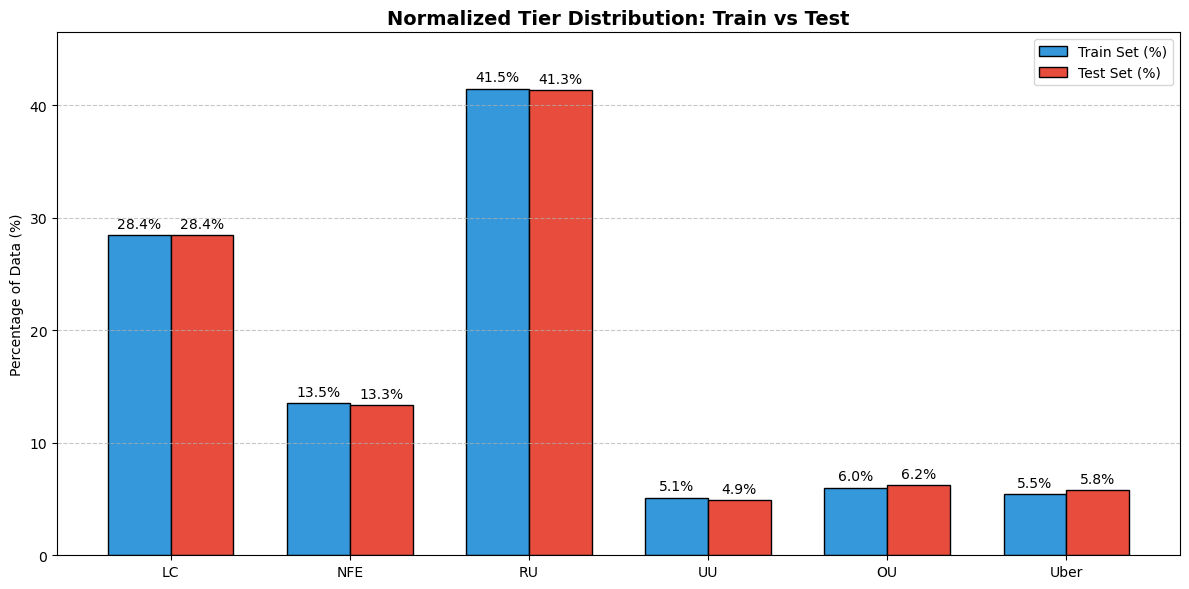

In [66]:
# graph train/test set tier frequency
tier_labels = ['LC', 'NFE', 'RU', 'UU', 'OU', 'Uber']

train_freq = (pd.Series(np.array(y_train).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)
test_freq = (pd.Series(np.array(y_test).ravel()).value_counts(normalize=True) * 100).reindex(range(len(tier_labels)), fill_value=0)

x = np.arange(len(tier_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width/2, train_freq, width, label='Train Set (%)', color='#3498db', edgecolor='black')
rects2 = ax.bar(x + width/2, test_freq, width, label='Test Set (%)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Percentage of Data (%)')
ax.set_title('Normalized Tier Distribution: Train vs Test', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_ylim(0, max(train_freq.max(), test_freq.max()) + 5)
ax.legend()

ax.bar_label(rects1, fmt='%.1f%%', padding=3)
ax.bar_label(rects2, fmt='%.1f%%', padding=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

In [52]:
'''
NOTE: objective: multi-softclass essentially tells the model it is doing a classification problem
given multiple classes like OU, UU, etc. choose the most fitting one and output; softmax converts tier scores->probabilities

'''

tier_model = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.1,
    max_depth=6,
    num_class=len(np.unique(y))
)

tier_model.fit(X_train, y_train)
predictions = tier_model.predict(X_test)


print(classification_report(y_test, predictions, zero_division=0))

mae = mean_absolute_error(y_test, predictions)


              precision    recall  f1-score   support

           0       0.94      0.98      0.96        64
           1       0.87      0.67      0.75        30
           2       0.77      0.88      0.82        93
           3       0.00      0.00      0.00        11
           4       0.36      0.36      0.36        14
           5       0.75      0.69      0.72        13

    accuracy                           0.80       225
   macro avg       0.62      0.60      0.60       225
weighted avg       0.77      0.80      0.78       225



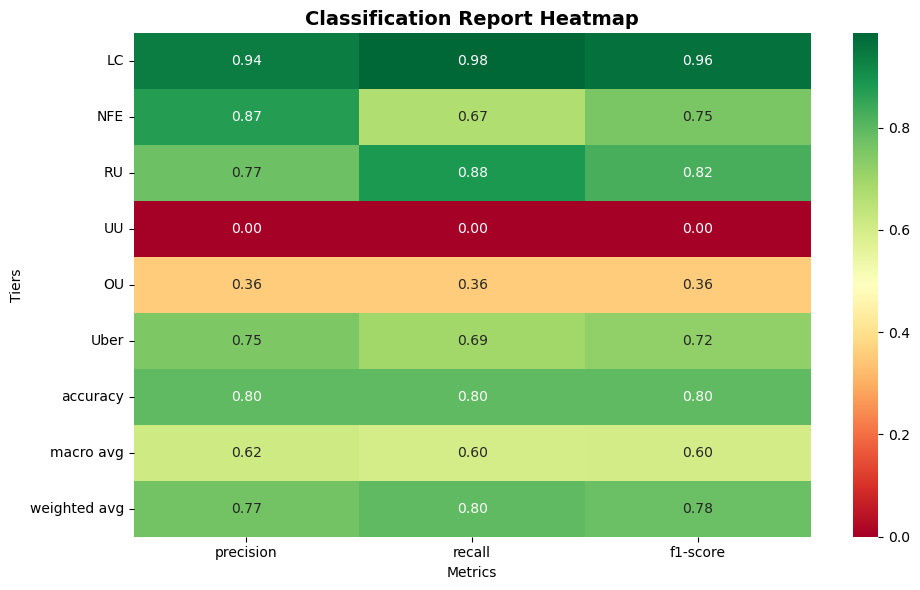

In [67]:
report_dict = classification_report(y_test, predictions, target_names=tier_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()

In [53]:
tier_rf = RandomForestClassifier(
    n_estimators=200, 
    max_depth=15, 
    max_features='sqrt',
    random_state=seed,
    class_weight='balanced_subsample' # chose because some tiers have very few mons
)

tier_rf.fit(X_train, y_train.values.ravel())
rf_predictions = tier_rf.predict(X_test)

# 4. EVALUATE
print("--- Random Forest Tier Prediction Results ---")
print(classification_report(y_test, rf_predictions, zero_division=0))

--- Random Forest Tier Prediction Results ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93        64
           1       1.00      0.50      0.67        30
           2       0.73      0.97      0.83        93
           3       1.00      0.09      0.17        11
           4       1.00      0.14      0.25        14
           5       0.82      0.69      0.75        13

    accuracy                           0.80       225
   macro avg       0.90      0.56      0.60       225
weighted avg       0.84      0.80      0.76       225



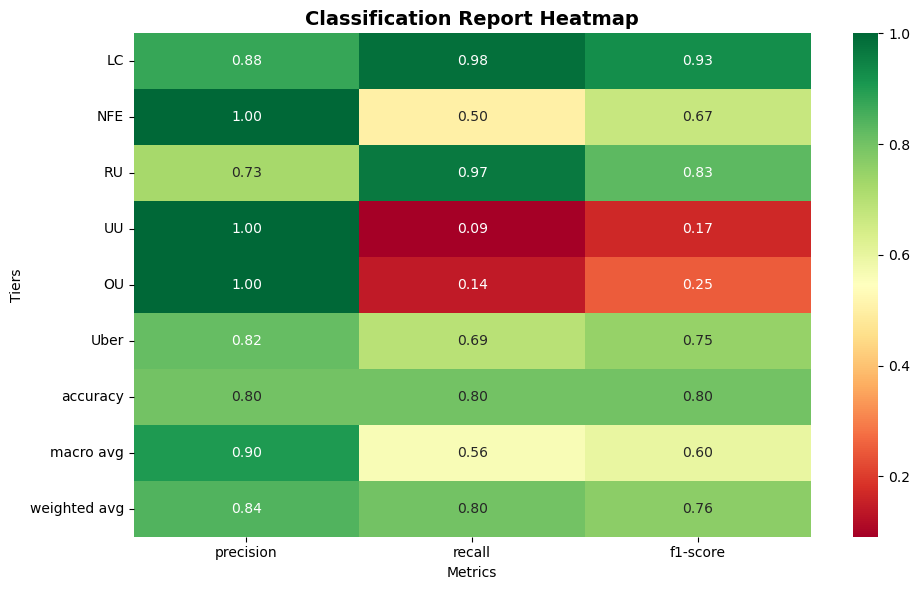

In [68]:
report_dict = classification_report(y_test, rf_predictions, target_names=tier_labels, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap='RdYlGn', fmt='.2f', ax=ax)

ax.set_title('Classification Report Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_ylabel('Tiers')

plt.tight_layout()
plt.show()